# 01 - Exploratory Data Analysis
Rental Marketplace Product Analytics Platform

Quick orientation pass over the warehouse: table sizes, date ranges,
and headline distributions before we move into the five required analyses.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
conn = sqlite3.connect("../data/warehouse.db")

tables = ["stg_landlords", "stg_properties", "stg_tenants" if False else "raw_tenants",
          "stg_applications", "stg_payments", "stg_events", "stg_market_monthly"]
for t in tables:
    n = conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"{t:<20} {n:>10,} rows")

stg_landlords            50,000 rows
stg_properties           78,279 rows
raw_tenants             150,000 rows
stg_applications        101,747 rows
stg_payments            275,052 rows
stg_events              228,531 rows
stg_market_monthly        2,850 rows


## Landlord signups over time

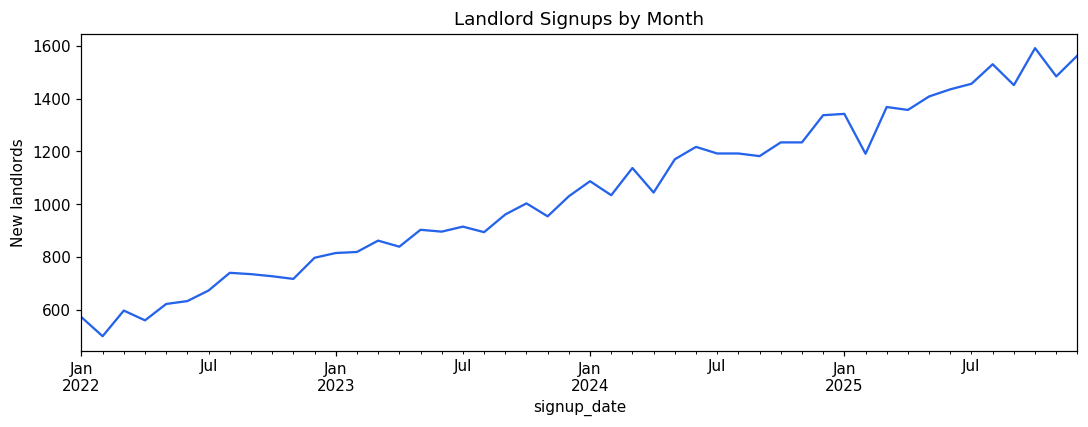

In [2]:
df = pd.read_sql("SELECT signup_date FROM stg_landlords", conn, parse_dates=["signup_date"])
monthly = df.set_index("signup_date").resample("MS").size()

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, color="#2563eb")
ax.set_title("Landlord Signups by Month")
ax.set_ylabel("New landlords")
plt.tight_layout()
plt.show()

## Portfolio size and experience mix

In [3]:
landlords = pd.read_sql("SELECT * FROM stg_landlords", conn)
print(landlords["experience_level"].value_counts(normalize=True).round(3))
print()
print(landlords["acquisition_channel"].value_counts(normalize=True).round(3))

experience_level
first_time      0.451
occasional      0.349
professional    0.200
Name: proportion, dtype: float64

acquisition_channel
organic_search    0.280
paid_social       0.196
paid_search       0.182
referral          0.143
content_seo       0.119
partnerships      0.080
Name: proportion, dtype: float64


## Activation and paid-conversion headline rates

In [4]:
activation_rate = landlords["activated_7d"].mean()
paid_rate = landlords["is_paid"].mean()
free_to_paid = landlords.loc[landlords["activated_7d"] == 1, "is_paid"].mean()
print(f"Overall 7-day activation rate: {activation_rate:.1%}")
print(f"Overall paid conversion rate: {paid_rate:.1%}")
print(f"Free-to-paid conversion (of activated): {free_to_paid:.1%}")

Overall 7-day activation rate: 40.6%
Overall paid conversion rate: 11.0%
Free-to-paid conversion (of activated): 25.5%


## Rent distribution by property type

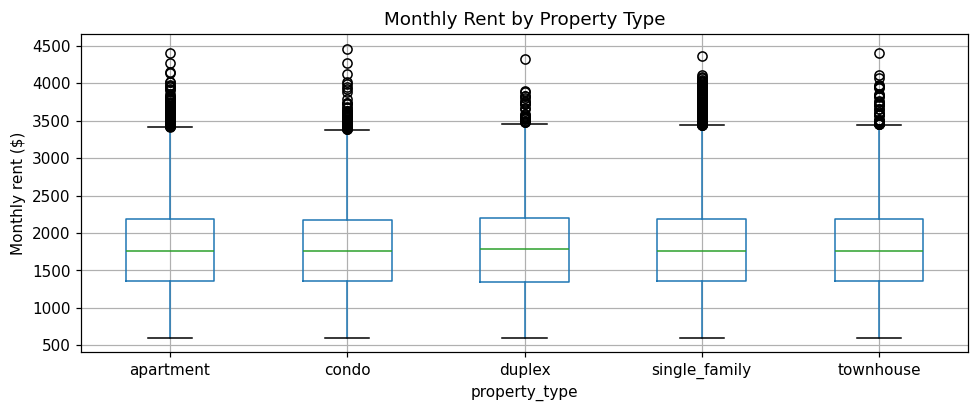

In [5]:
props = pd.read_sql("SELECT property_type, monthly_rent FROM stg_properties", conn)
fig, ax = plt.subplots(figsize=(9, 4))
props.boxplot(column="monthly_rent", by="property_type", ax=ax)
ax.set_title("Monthly Rent by Property Type")
plt.suptitle("")
ax.set_ylabel("Monthly rent ($)")
plt.tight_layout()
plt.show()

Data looks internally consistent: signups grow over time as expected from
the platform-growth weighting in the generator, activation and paid-conversion
rates land in plausible SaaS-marketplace ranges, and rent distributions vary
sensibly by property type. Proceeding to the five required analyses.